# Nonlinear Oscillators, Lyapunov Exponents, and Bifurcations

Damping scans, amplitude-dependent oscillator periods, trajectory separation, and period-doubling bifurcations.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


Saved: problem1_poincare_vs_q.png
Saved: problem1_dt_convergence.png


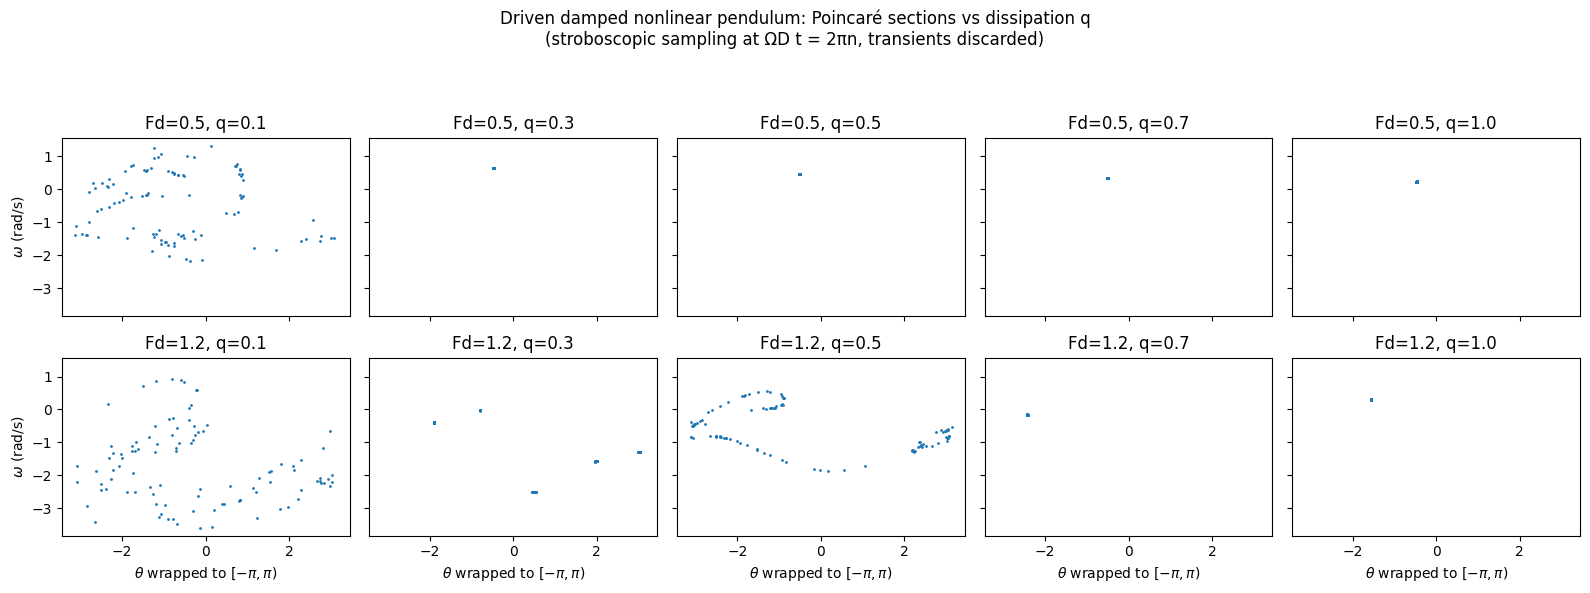

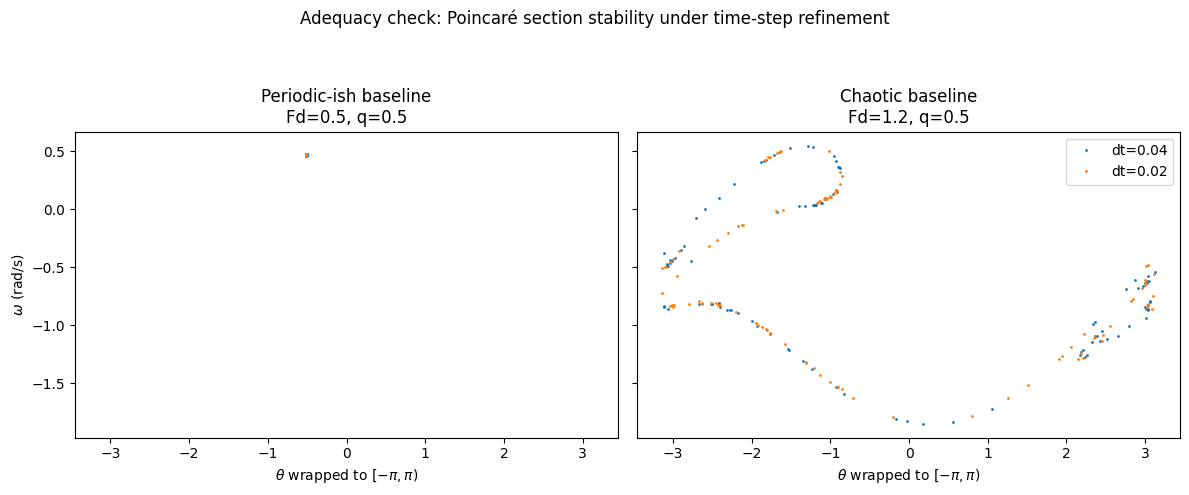

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Helpers
# -----------------------------
def wrap_theta(theta):
    """Wrap angle to [-pi, pi)."""
    return (theta + np.pi) % (2 * np.pi) - np.pi


def poincare_points(
    g_over_l=1.0,
    q=0.5,
    Fd=1.2,
    OmegaD=2 / 3,
    dt=0.04,
    theta0=0.2,
    omega0=0.0,
    start_period=200,
    end_period=300,
):
    """
    Integrate driven, damped, nonlinear pendulum using Euler–Cromer.

    ODE:
        dtheta/dt = omega
        domega/dt = -(g/l) sin(theta) - q*omega + Fd*sin(OmegaD*t)

    Poincaré section:
        sample (theta, omega) when OmegaD * t = 2*pi*n (stroboscopic times)

    We discard transient by only recording n in [start_period, end_period].
    """
    theta = float(theta0)
    omega = float(omega0)
    t = 0.0

    pts_theta = []
    pts_omega = []

    # "Hit test" tolerance in fractional phase:
    # We sample when frac = OmegaD*t/(2*pi) is near an integer.
    # This tol corresponds roughly to |t - n*T_D| < dt/2.
    tol = OmegaD * dt / (4 * np.pi)

    current_period = 0
    while current_period <= end_period:
        # Euler–Cromer update: omega first, then theta (semi-implicit Euler)
        omega += (-g_over_l * np.sin(theta) - q * omega + Fd * np.sin(OmegaD * t)) * dt
        theta += omega * dt
        t += dt

        frac = OmegaD * t / (2 * np.pi)
        nearest = round(frac)

        if abs(frac - nearest) < tol:
            current_period = int(nearest)
            if start_period <= current_period <= end_period:
                pts_theta.append(wrap_theta(theta))
                pts_omega.append(omega)

    return np.array(pts_theta), np.array(pts_omega)


def compare_dt(Fd, q, dts=(0.04, 0.02), start_period=200, end_period=300):
    """Return Poincaré datasets for multiple dt values for the same (Fd,q)."""
    out = []
    for dt_ in dts:
        th, om = poincare_points(
            g_over_l=1.0,
            q=q,
            Fd=Fd,
            OmegaD=2 / 3,
            dt=dt_,
            theta0=0.2,
            omega0=0.0,
            start_period=start_period,
            end_period=end_period,
        )
        out.append((dt_, th, om))
    return out


# -----------------------------
# Main: parameters from Fig 3.6
# -----------------------------
g_over_l = 1.0          # because g = l = 9.8 -> g/l = 1 in the dimensionless form used here
OmegaD = 2 / 3
dt = 0.04
theta0, omega0 = 0.2, 0.0

# Scan q
q_values = [0.1, 0.3, 0.5, 0.7, 1.0]

Fd_periodic = 0.5   # part (a) baseline: periodic regime
Fd_chaotic = 1.2    # part (b) baseline: chaotic regime

# Choose how many periods to discard / keep for Poincaré
start_period = 200
end_period = 300

# -----------------------------
# Figure 1: Poincaré vs q (two Fd cases)
# -----------------------------
fig, axes = plt.subplots(2, len(q_values), figsize=(16, 6), sharex=True, sharey=True)

for j, q in enumerate(q_values):
    th, om = poincare_points(
        g_over_l=g_over_l,
        q=q,
        Fd=Fd_periodic,
        OmegaD=OmegaD,
        dt=dt,
        theta0=theta0,
        omega0=omega0,
        start_period=start_period,
        end_period=end_period,
    )
    ax = axes[0, j]
    ax.plot(th, om, ".", ms=2)
    ax.set_title(f"Fd=0.5, q={q}")
    if j == 0:
        ax.set_ylabel(r"$\omega$ (rad/s)")

for j, q in enumerate(q_values):
    th, om = poincare_points(
        g_over_l=g_over_l,
        q=q,
        Fd=Fd_chaotic,
        OmegaD=OmegaD,
        dt=dt,
        theta0=theta0,
        omega0=omega0,
        start_period=start_period,
        end_period=end_period,
    )
    ax = axes[1, j]
    ax.plot(th, om, ".", ms=2)
    ax.set_title(f"Fd=1.2, q={q}")
    ax.set_xlabel(r"$\theta$ wrapped to $[-\pi,\pi)$")
    if j == 0:
        ax.set_ylabel(r"$\omega$ (rad/s)")

fig.suptitle(
    "Driven damped nonlinear pendulum: Poincaré sections vs dissipation q\n"
    "(stroboscopic sampling at ΩD t = 2πn, transients discarded)"
)
fig.tight_layout(rect=[0, 0, 1, 0.92])

fig1_path = "problem1_poincare_vs_q.png"
fig.savefig(fig1_path, dpi=200)
print("Saved:", fig1_path)

# -----------------------------
# Figure 2: dt refinement / adequacy check
# -----------------------------
cases = [
    ("Periodic-ish baseline", 0.5, 0.5),
    ("Chaotic baseline", 1.2, 0.5),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, (title, Fd, q) in zip(axes, cases):
    for dt_, th, om in compare_dt(Fd, q, dts=(0.04, 0.02), start_period=start_period, end_period=end_period):
        ax.plot(th, om, ".", ms=2, label=f"dt={dt_}")
    ax.set_title(f"{title}\nFd={Fd}, q={q}")
    ax.set_xlabel(r"$\theta$ wrapped to $[-\pi,\pi)$")

axes[0].set_ylabel(r"$\omega$ (rad/s)")
axes[1].legend(loc="best")

fig.suptitle("Adequacy check: Poincaré section stability under time-step refinement")
fig.tight_layout(rect=[0, 0, 1, 0.92])

fig2_path = "problem1_dt_convergence.png"
fig.savefig(fig2_path, dpi=200)
print("Saved:", fig2_path)

plt.show()


In [ ]:
import numpy as np

def wrap_theta(theta):
    return (theta + np.pi) % (2*np.pi) - np.pi;

def poincare_points(g_over_l = 1.0, q = 0.5, Fd = 1.2, OmegaD = 2/3, dt = 0.04, theta0 = 0.2, omega0 = 0.0,
                    start_period=200, end_period=300):

    theta = theta0;
    omega = omega0;
    t = 0.0;

    pts_theta, pts_omega = [], [];
    tol = OmegaD * dt / (4*np.pi);  # equivalent to abs(t - 2πn/ΩD) < dt/2

    current_period = 0;
    while current_period <= end_period:
        # Euler–Cromer step: update omega, then theta
        omega = omega + (-g_over_l*np.sin(theta) - q*omega + Fd*np.sin(OmegaD*t)) * dt;
        theta = theta + omega * dt;
        t += dt;

        frac = OmegaD * t / (2*np.pi);
        nearest = round(frac);
        if abs(frac - nearest) < tol:
            current_period = int(nearest);
            if start_period <= current_period <= end_period:
                pts_theta.append(wrap_theta(theta));
                pts_omega.append(omega);

    return np.array(pts_theta), np.array(pts_omega);


In [ ]:
import numpy as np

def accel(x, k = 1.0, alpha = 1.0):
    # a = -k * sgn(x) * |x|^alpha;
    return -k * np.sign(x) * (np.abs(x) ** alpha);

def euler_cromer_oscillator(A = 1.0, alpha = 1.0, k = 1.0, dt = 1e-3, tmax = 50.0):
    n = int(np.ceil(tmax/dt));
    t = np.linspace(0, n * dt, n + 1);
    x = np.zeros(n+1); v = np.zeros(n + 1);
    x[0] = A; v[0] = 0.0;

    for i in range(n):
        v[i+1] = v[i] + accel(x[i], k = k, alpha = alpha) * dt;
        x[i+1] = x[i] + v[i+1] * dt;

    return t, x, v;

def quarter_period_from_first_zero_crossing(t, x):
    # first crossing from x>0 to x<0; linear interpolation
    for i in range(1, len(x)):
        if x[i] <= 0.0 and x[i-1] > 0.0:
            frac = x[i-1] / (x[i-1] - x[i]);
            return t[i-1] + frac * (t[i] - t[i-1]);
    return np.nan;

def period_estimate(A, alpha, dt):
    tmax = 20.0 if alpha == 1 else min(200.0, 60.0/max(A, 0.05));
    t, x, v = euler_cromer_oscillator(A = A, alpha = alpha, dt = dt, tmax = tmax);
    tq = quarter_period_from_first_zero_crossing(t, x);
    return 4.0 * tq;


In [ ]:
import numpy as np

def wrap(x):
    return ((x + np.pi) % (2*np.pi)) - np.pi;

def simulate_two_pendulums(g_over_l = 1.0, q = 0.5, OmegaD = 2/3, Fd = 1.2, dt = 0.04, endT = 150.0, theta1_0 = 0.2, theta2_0 = 0.201,
                           omega1_0 = 0.0, omega2_0 = 0.0):
    npts = int(np.ceil(endT/dt)) + 1;
    t = np.arange(npts) * dt;

    th1 = np.zeros(npts); th2 = np.zeros(npts);
    om1 = np.zeros(npts); om2 = np.zeros(npts);
    th1[0] = theta1_0;
    th2[0] = theta2_0;
    om1[0] = omega1_0;
    om2[0] = omega2_0;

    for i in range(1, npts):
        ti = t[i-1];
        # Euler–Cromer step for pendulum 1
        om1[i] = om1[i-1] + ((-g_over_l*np.sin(th1[i-1])) - q*om1[i-1] + Fd*np.sin(OmegaD*ti)) * dt;
        th1[i] = th1[i-1] + om1[i] * dt;
        # Euler–Cromer step for pendulum 2
        om2[i] = om2[i-1] + ((-g_over_l*np.sin(th2[i-1])) - q*om2[i-1] + Fd*np.sin(OmegaD*ti)) * dt;
        th2[i] = th2[i-1] + om2[i] * dt;

    # minimal angular separation modulus 2π
    dtheta = np.abs(wrap(th2 - th1));
    return t, dtheta;

def estimate_lambda_from_envelope(t, dtheta, tmin = 10.0, tmax = 60.0, dmin = 1e-6, dmax = 0.5):
    envelope = np.maximum.accumulate(dtheta);     # simple upper envelope
    mask = (t >= tmin) & (t <= tmax) & (envelope >= dmin) & (envelope <= dmax); # interesting boolean mask
    x = t[mask];
    y = np.log(envelope[mask]);
    m, b = np.polyfit(x, y, 1);            # slope m ≈ λ
    return m, b, envelope;


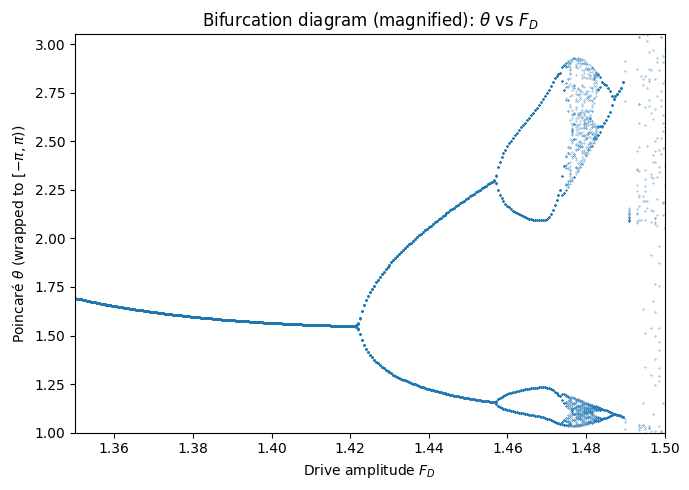

mu1,mu2,mu3,mu4 = 1.4215776634216306 1.456660327911377 1.4736877307891847 1.4827922039031984
delta3, delta4 = 2.0603649741247776 1.870223862993109


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters (Giordano–Nakanishi Chap 3)
g_over_l = 1.0
q = 0.5
OmegaD = 2/3

def wrap_theta(theta):
    return ((theta + np.pi) % (2*np.pi)) - np.pi;

def make_drive_table(dt):
    # Precompute sin(OmegaD t) over one drive period; repeats every period
    Tdrive = 2*np.pi / OmegaD;
    nsteps = int(round(Tdrive / dt));
    dt_eff = Tdrive / nsteps;
    t_in = np.arange(nsteps) * dt_eff;
    drive = np.sin(OmegaD * t_in);
    return dt_eff, nsteps, drive;

def poincare_theta_samples(Fd, dt = 0.02, n_trans = 200, n_keep = 60, theta0 = 0.2, omega0 = 0.0, dt_eff = None, nsteps = None, drive = None):
    # Euler–Cromer integrate and strobe once per drive period. Returns last n_keep wrapped theta values.
    if dt_eff is None:
        dt_eff, nsteps, drive = make_drive_table(dt);

    theta, omega = theta0, omega0;
    kept = np.empty(n_keep);
    keep_i = 0;

    for p in range(n_trans + n_keep):
        for s in range(nsteps):
            omega += (-g_over_l*np.sin(theta) - q*omega + Fd*drive[s]) * dt_eff;
            theta += omega * dt_eff;
        if p >= n_trans:
            kept[keep_i] = wrap_theta(theta);
            keep_i += 1;

    return kept;

def wrapped_diff(a, b):
    return ((a - b + np.pi) % (2*np.pi)) - np.pi;

def is_period(samples, p, tol=2e-3):
    # Check theta[n+p] ~ theta[n] on the tail; reject smaller divisors
    if len(samples) < 2*p + 5:
        return False
    d = wrapped_diff(samples[p:], samples[:-p])
    if np.max(np.abs(d)) > tol:
        return False
    if p % 2 == 0:
        d2 = wrapped_diff(samples[p//2:], samples[:-p//2])
        if np.max(np.abs(d2)) <= tol:
            return False
    return True

def has_period(F, p, dt_eff, nsteps, drive):
    s = poincare_theta_samples(F, dt = 0.02, n_trans = 350, n_keep = 200, dt_eff = dt_eff, nsteps = nsteps, drive = drive);
    return is_period(s, p);

def bisect_bifurcation(p, lo, hi, dt_eff, nsteps, drive, iters = 20):
    # Return the smallest F in [lo,hi] where period-p is detected.
    for _ in range(iters):
        mid = 0.5*(lo + hi);
        if has_period(mid, p, dt_eff, nsteps, drive):
            hi = mid;
        else:
            lo = mid;
    return hi;

# Build bifurcation diagram first
dt_eff, nsteps, drive = make_drive_table(dt = 0.02);

F_vals = np.linspace(1.35, 1.50, 301);
n_trans, n_keep = 200, 60;

Xs, Ys = [], [];
for F in F_vals:
    s = poincare_theta_samples(F, dt = 0.02, n_trans = n_trans, n_keep = n_keep, dt_eff = dt_eff, nsteps = nsteps, drive = drive);
    Xs.append(np.full_like(s, F));
    Ys.append(s);

Xs = np.concatenate(Xs);
Ys = np.concatenate(Ys);

plt.figure(figsize = (7,5));
plt.plot(Xs, Ys, ".", ms = 0.5);
plt.xlim(1.35, 1.50);
plt.ylim(1.0, 3.05);
plt.xlabel(r"Drive amplitude $F_D$");
plt.ylabel(r"Poincaré $\theta$ (wrapped to $[-\pi,\pi)$)");
plt.title(r"Bifurcation diagram (magnified): $\theta$ vs $F_D$");
plt.tight_layout();
plt.show();

# Estimate period-doubling points and delta-like ratios
mu1 = bisect_bifurcation(2, 1.40, 1.43, dt_eff, nsteps, drive);
mu2 = bisect_bifurcation(4, 1.44, 1.46, dt_eff, nsteps, drive);
mu3 = bisect_bifurcation(8, 1.465, 1.474, dt_eff, nsteps, drive);
mu4 = bisect_bifurcation(16, 1.474, 1.483, dt_eff, nsteps, drive);

delta3 = (mu2 - mu1) / (mu3 - mu2);
delta4 = (mu3 - mu2) / (mu4 - mu3);

print("mu1,mu2,mu3,mu4 =", mu1, mu2, mu3, mu4);
print("delta3, delta4 =", delta3, delta4);
